In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df_salary = pd.read_csv("datasets/Salary_dataset.csv")

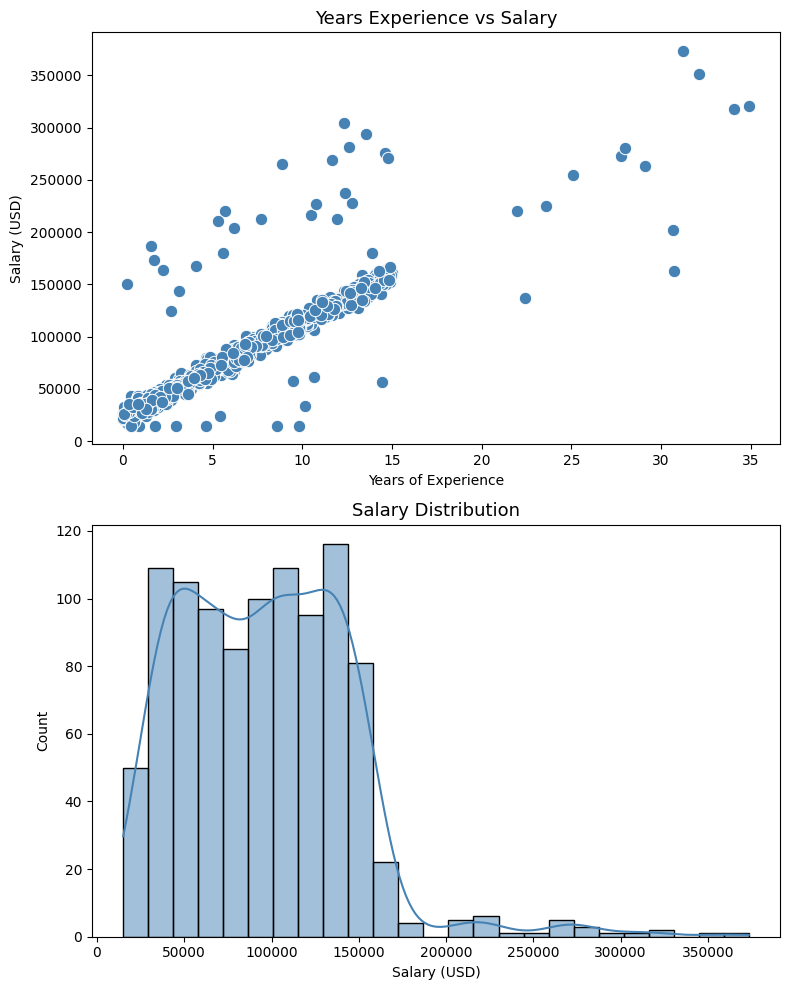

,YearsExperience,Salary
count,1000.000000,1000.000000
mean,7.708930,95921.584000
std,4.984305,49191.786632
min,0.020000,15000.000000
25%,3.610000,56117.500000
50%,7.535000,94556.500000
75%,11.485000,129708.000000
max,34.890000,373379.000000


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Scatter plot
sns.scatterplot(data=df_salary, x='YearsExperience', y='Salary', ax=axes[0], color='steelblue', s=80)
axes[0].set_title('Years Experience vs Salary', fontsize=13)
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary (USD)')

# Distribution
sns.histplot(df_salary['Salary'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Salary Distribution', fontsize=13)
axes[1].set_xlabel('Salary (USD)')

plt.tight_layout()
plt.savefig('images/exploratory_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
display(df_salary.describe())



#### Estas observaciones previas de la data tuvieron el fin de apreciar cómo se encuentran distribuidos los datos.

### VARIABLES 

Para este ejercicio consideramos `YearsExperience`, la variable predictora; y `Salary`, la variable a predecir

In [15]:
X = df_salary['YearsExperience'].values
y = df_salary['Salary'].values

### MINIMOS CUADRADOS ORDINARIOS

En este caso, solo tenemos una variable 'x' y por tanto la forma más indicada para nuestro modelo de predicción es la siguiente:

$$\hat{\beta_{1}} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}, \quad \hat{\beta_{0}} = \bar{y} - \hat{\beta_{1}}\bar{x}$$



In [16]:
x_media = np.mean(X)
y_media = np.mean(y)

numerador   = np.sum((X - x_media) * (y - y_media))  # Cov(x, y) * n
denominador = np.sum((X - x_media) ** 2)             # Var(x) * n

beta1_mco = numerador / denominador
beta0_mco = y_media - beta1_mco * x_media


### DESCENSO DEL GRADIENTE.
#### Forma para la Regresión Lineal Simple

$$\hat{y} = \hat{\beta_{1}} \cdot x + \hat{\beta_{0}}$$

### Error Cuadrático Medio.
$$\text{ECM} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

### Gradientes
$$\frac{\partial \text{ECM}}{\partial \hat{\beta_{1}}} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot x_i$$
$$\frac{\partial \text{ECM}}{\partial \hat{\beta_{0}}} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

### Actualización de parámetros
$$\hat{\beta}_{1} \text{ pasa a ser: } \hat{\beta}_{1} - \alpha \cdot \frac{\partial \text{ECM}}{\partial \hat{\beta}_{1}}$$

$$\hat{\beta}_{0} \text{ pasa a ser: } \hat{\beta}_{0} - \alpha \cdot \frac{\partial \text{ECM}}{\partial \hat{\beta}_{0}}$$

In [ ]:
## DESCENSO DEL GRADIENTE
def ecm(y, y_estimado):
    return np.mean((y_estimado - y) ** 2)

def gradiente(X, y, beta1, beta0):
    n = len(y)
    y_estimado = beta1 * X + beta0
    error = y_estimado - y
    dbeta1 = (2 / n) * np.dot(error, X)
    dbeta0 = (2 / n) * np.sum(error)
    return dbeta1, dbeta0



beta1_desc, beta0_desc = 0.0, 0.0          # inicializando parámetros
iteraciones = 1000
hist = []
taza_aprendizaje = 0.01

X = df_salary['YearsExperience'].values
y = df_salary['Salary'].values


for iteracion in range(iteraciones):
    y_pred = beta1_desc * X + beta0_desc #se ajusta recta a parametros actuales
    perdida = ecm(y, y_pred) #se calcula la perdida o error cuadratico medio
    hist.append(perdida)

    dbeta1, dbeta0 = gradiente(X, y, beta1_desc, beta0_desc)

    # Update parameters
    beta1_desc -= taza_aprendizaje * dbeta1
    beta0_desc -= taza_aprendizaje * dbeta0

    if iteracion % 200 == 0:
        print(f"iteracion {iteracion:>5} | ECM: {perdida:>15,.2f} | beta1_desc: {beta1_desc:.4f} | beta0_desc: {beta0_desc:.4f}")

iteracion     0 | ECM: 11,618,362,317.21 | beta1_desc: 19179.9558 | beta0_desc: 1918.4317
iteracion   200 | ECM:  495,444,789.97 | beta1_desc: 9600.7513 | beta0_desc: 19508.9125
iteracion   400 | ECM:  477,240,287.87 | beta1_desc: 9079.8116 | beta0_desc: 25182.1940
iteracion   600 | ECM:  475,493,649.62 | beta1_desc: 8918.4502 | beta0_desc: 26939.4961
iteracion   800 | ECM:  475,326,067.71 | beta1_desc: 8868.4685 | beta0_desc: 27483.8213


## COMPARACIÓN Y VISUALIZACIÓN

### Comparar los parámetros obtenidos por ambos métodos

In [9]:
print(f"Párametros hallados mediante la formula análitica mco beta1_mco: {beta1_mco :.4f} | beta0_mco: {beta0_mco:.4f}")
print(f"Párametros hallados mediante descenso del gradiente beta1_desc: {beta1_desc :.4f} | beta0_desc: {beta0_desc:.4f}")

Párametros hallados mediante la formula análitica mco beta1_mco: 8846.0391 | beta0_mco: 27728.0882
Párametros hallados mediante descenso del gradiente beta1_desc: 8853.0274 | beta0_desc: 27651.9817


### Analizar si los resultados coinciden o presentan diferencias.

In [10]:
def r_cuadrado(y, y_estimado):
    ss_res = np.sum((y - y_estimado) ** 2)
    ss_tot = np.sum((y - np.mean(y_estimado)) ** 2)
    return 1 - ss_res / ss_tot

y_pred_mco = beta1_mco * X + beta0_mco
y_pred_desc = beta1_desc * X + beta0_desc

print("=" * 55)
print("MCO ")
print(f"  beta1 (pendiente)      : {beta1_mco:>12,.4f}")
print(f"  beta0 (punto de corte) : {beta0_mco:>12,.4f}")
print(f"  ECM                    : {ecm(y, y_pred_mco):>12,.2f}")
print(f"  R²                     : {r_cuadrado(y, y_pred_mco):>12,.6f}")
print()
print("Descenso del gradiente")
print(f"  beta1 (pendiente)      : {beta1_desc:>12,.4f}")
print(f"  beta0 (punto de corte) : {beta0_desc:>12,.4f}")
print(f"  ECM                    : {ecm(y, y_pred_desc):>12,.2f}")
print(f"  R²                     : {r_cuadrado(y, y_pred_desc):>12,.6f}")
print("=" * 55)


MCO 
  beta1 (pendiente)      :   8,846.0391
  beta0 (punto de corte) :  27,728.0882
  ECM                    : 475,308,282.60
  R²                     :     0.803381

Descenso del gradiente
  beta1 (pendiente)      :   8,853.0274
  beta0 (punto de corte) :  27,651.9817
  ECM                    : 475,309,989.00
  R²                     :     0.803381


### Graficar los datos originales `YearsExperience` vs `Salary` | superponer en el mismo gráfico las rectas obtenidas por ambos métodos.

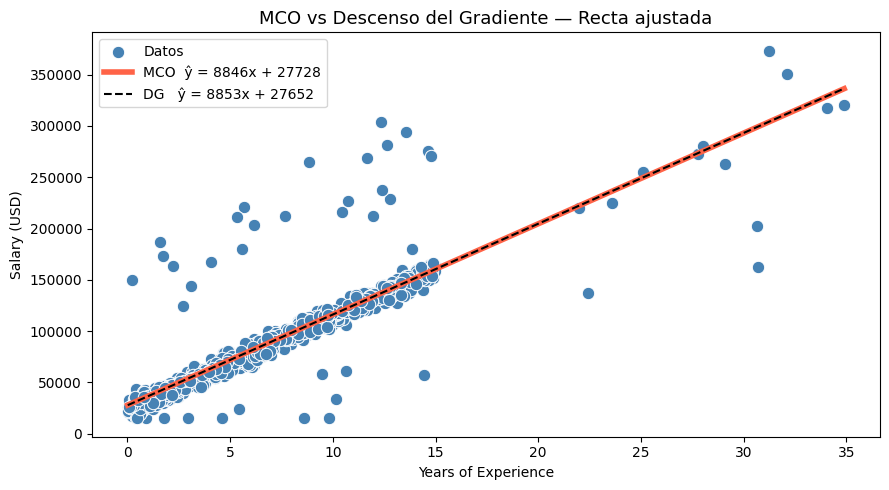

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

x_line = np.linspace(X.min(), X.max(), 200)
y_mco_line  = beta1_mco  * x_line + beta0_mco
y_desc_line = beta1_desc * x_line + beta0_desc

sns.scatterplot(x=X, y=y, ax=ax, color='steelblue', s=80, label='Datos')
ax.plot(x_line, y_mco_line,  color='tomato', linewidth=4,   linestyle='-',  label=f'MCO  ŷ = {beta1_mco:.0f}x + {beta0_mco:.0f}')
ax.plot(x_line, y_desc_line, color='black', linewidth=1.5, linestyle='--', label=f'DG   ŷ = {beta1_desc:.0f}x + {beta0_desc:.0f}')

ax.set_title('MCO vs Descenso del Gradiente — Recta ajustada', fontsize=13)
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Salary (USD)')
ax.legend()

plt.tight_layout()
plt.savefig('images/regresion_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()




### Graficar la evolución de la función de pérdida durante las iteraciones del Descenso del Gradiente

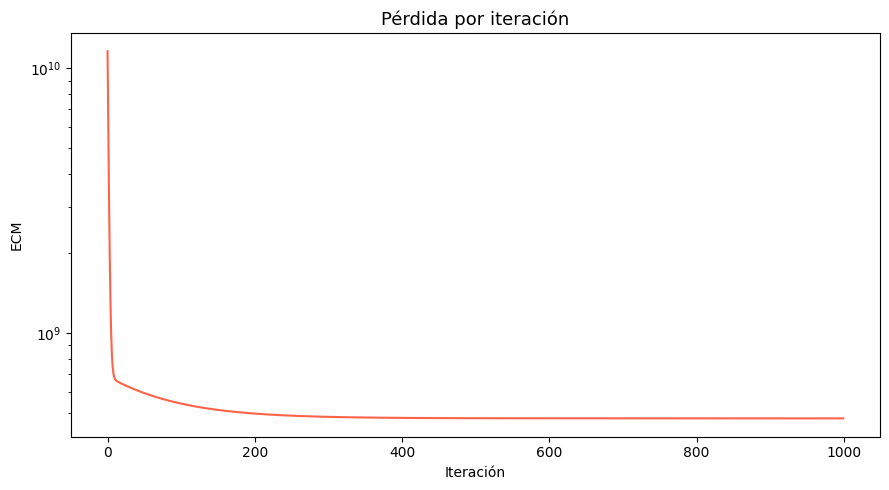

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(hist, color='tomato', linewidth=1.5)
ax.set_title('Pérdida por iteración', fontsize=13)
ax.set_xlabel('Iteración')
ax.set_ylabel('ECM')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('images/funcion_perdida.png', dpi=300, bbox_inches='tight')
plt.show()